In [76]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from ant.market import Market, BaseAgent
from ant.decentralised.direct import ProportionalAgent, EqualDivisionAgent, OptimalAgent
from ant.decentralised.neighbours import RecirpocateAgent, MaxFinder
from ant.decentralised.dynamic import OptimizerAgent
from ant.centralised import P4

In [77]:
seed_1 = 42
size_1 = 8
pos_seed_1 = 1111

G_1 = nx.gnp_random_graph(size_1, 0.2, seed=seed_1)

pos_1 = nx.spring_layout(G_1, seed=pos_seed_1)

agent_color = "#4ECDFF"
neighbour_color = "#FF6B6B"
node_color = "#CACACA"


node_colors_1 = [
    node_color,
    node_color,
    neighbour_color,
    agent_color,
    node_color,
    neighbour_color,
    node_color,
    node_color,
]

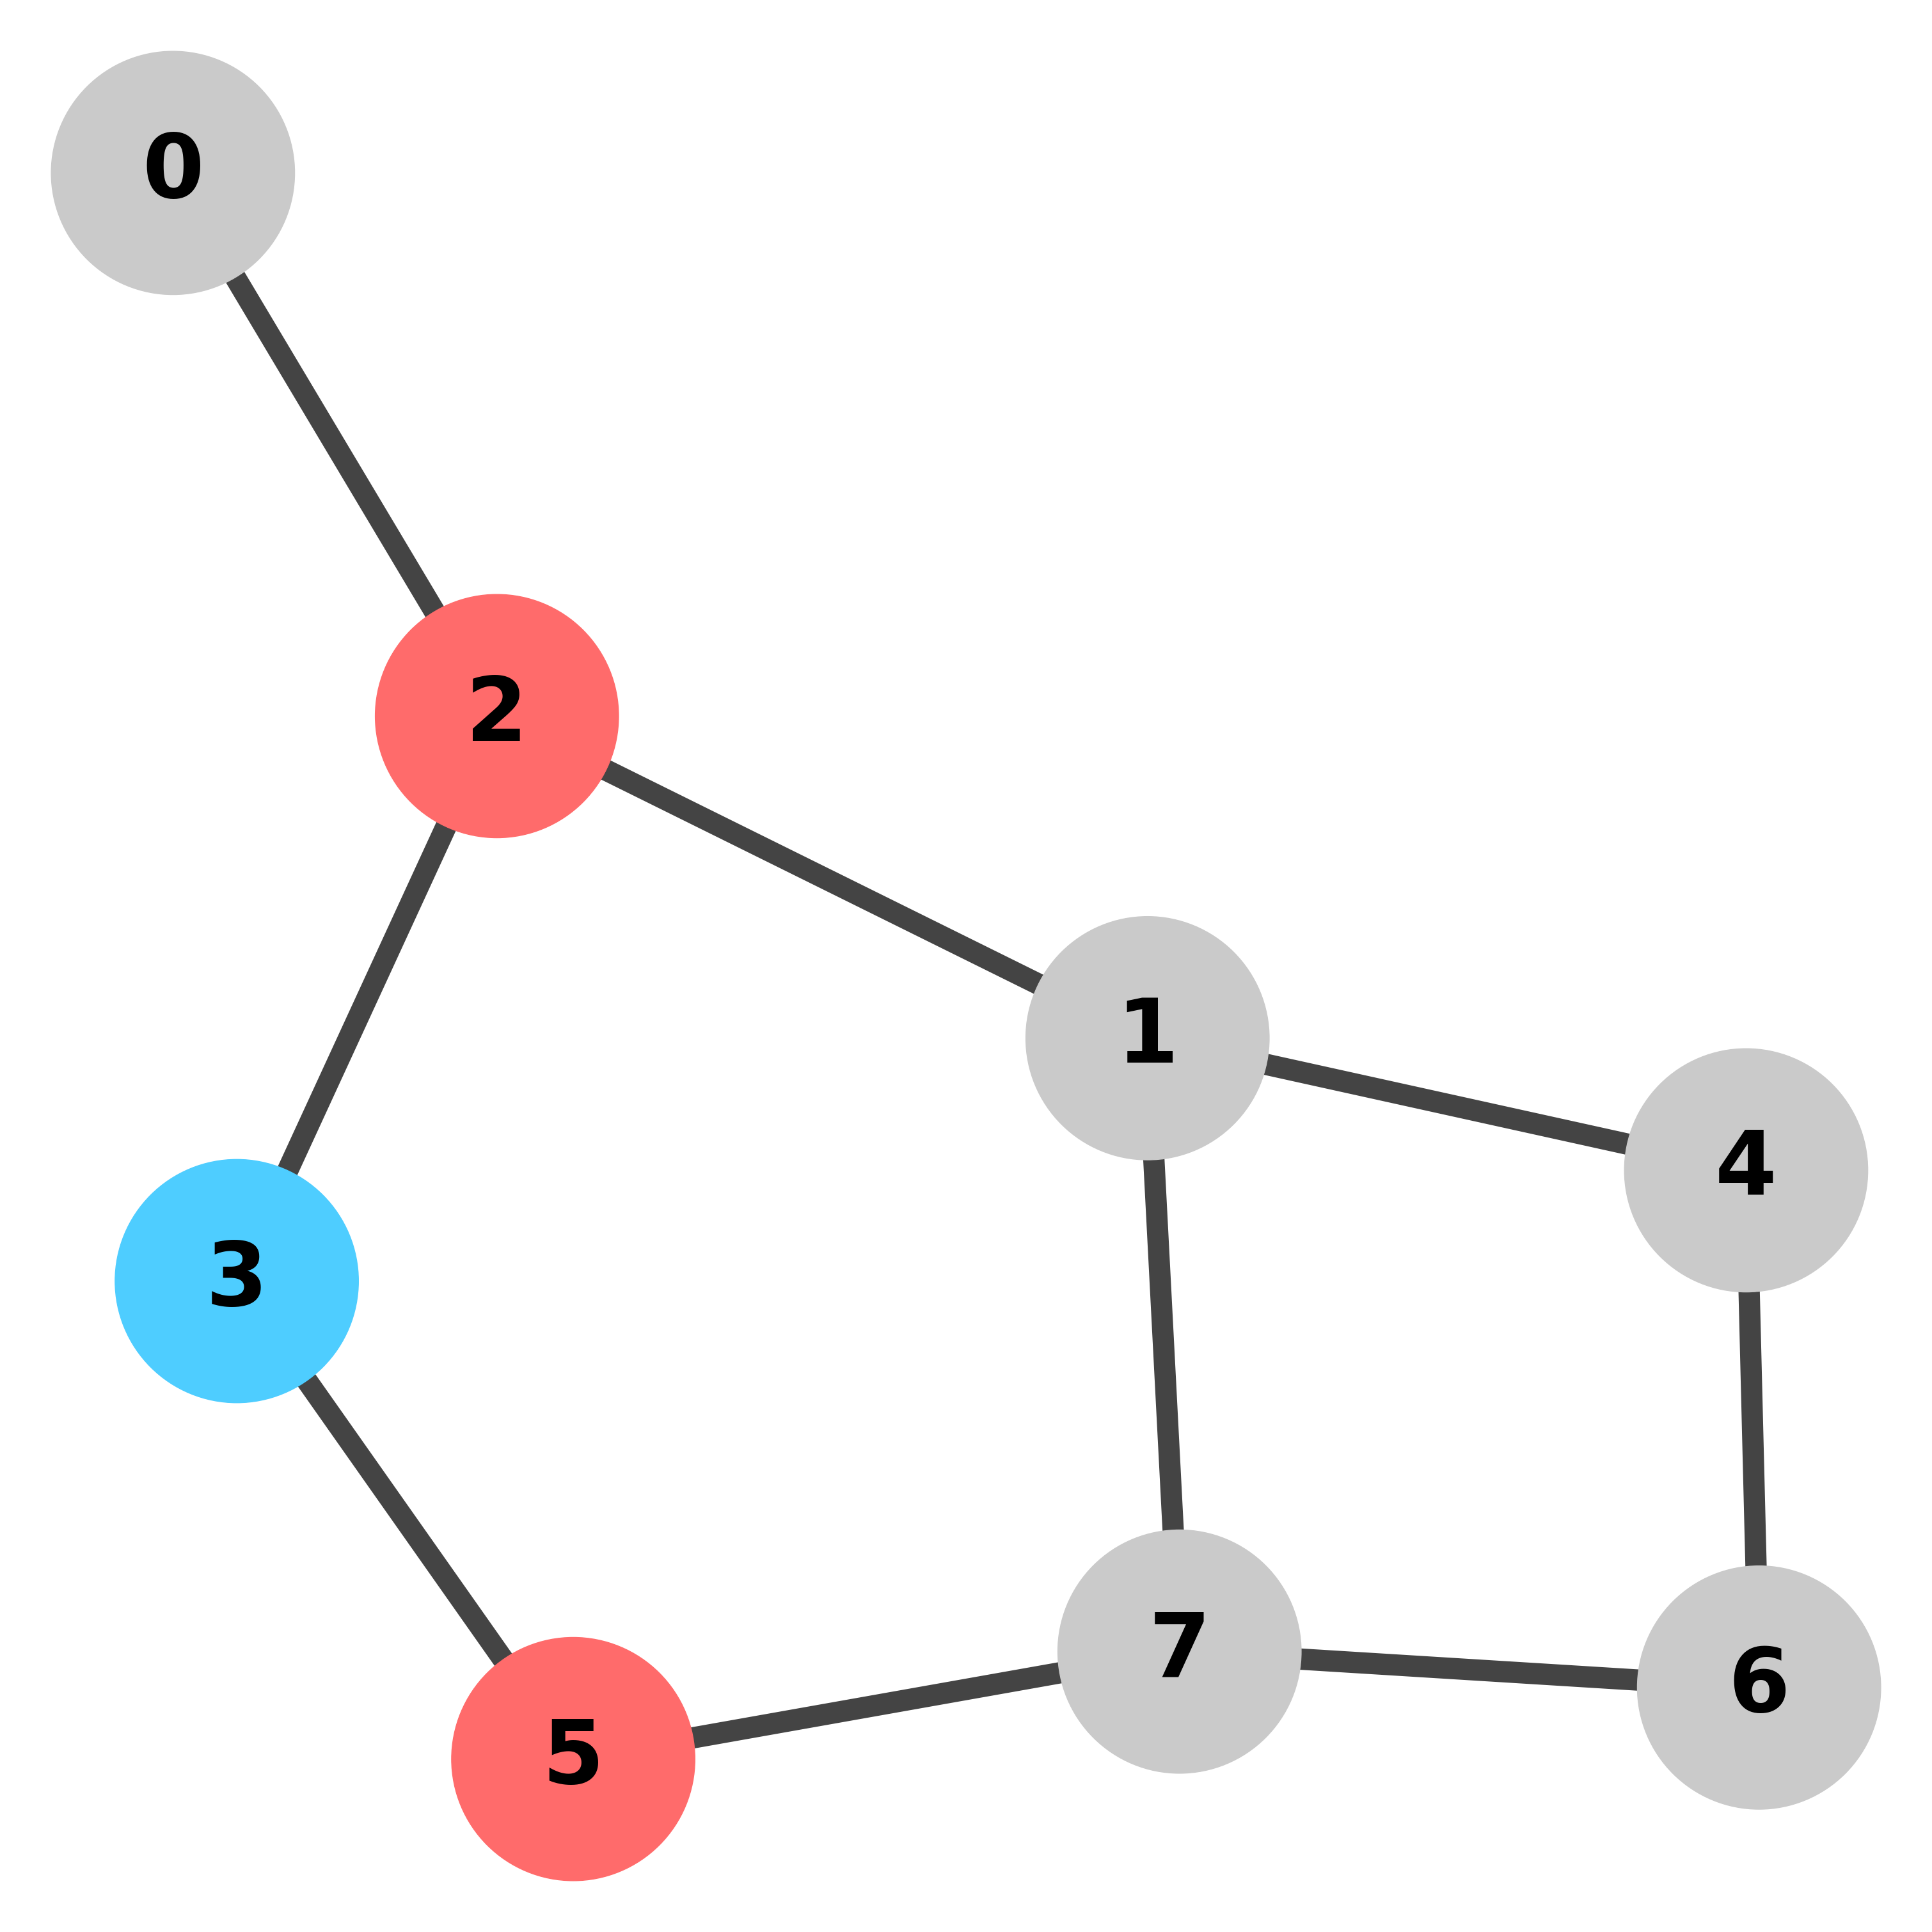

In [78]:
# nx.draw(G_1, with_labels=True, pos=pos_1)
plt.figure(figsize=(30, 30))
nx.draw(
    G_1,
    pos=pos_1,
    node_color=node_colors_1,
    node_size=75000,
    node_shape="o",
    edge_color="#444444",
    width=24,
    with_labels=True,
    font_size=100,
    font_color="black",
    font_weight="bold",
)
plt.draw()

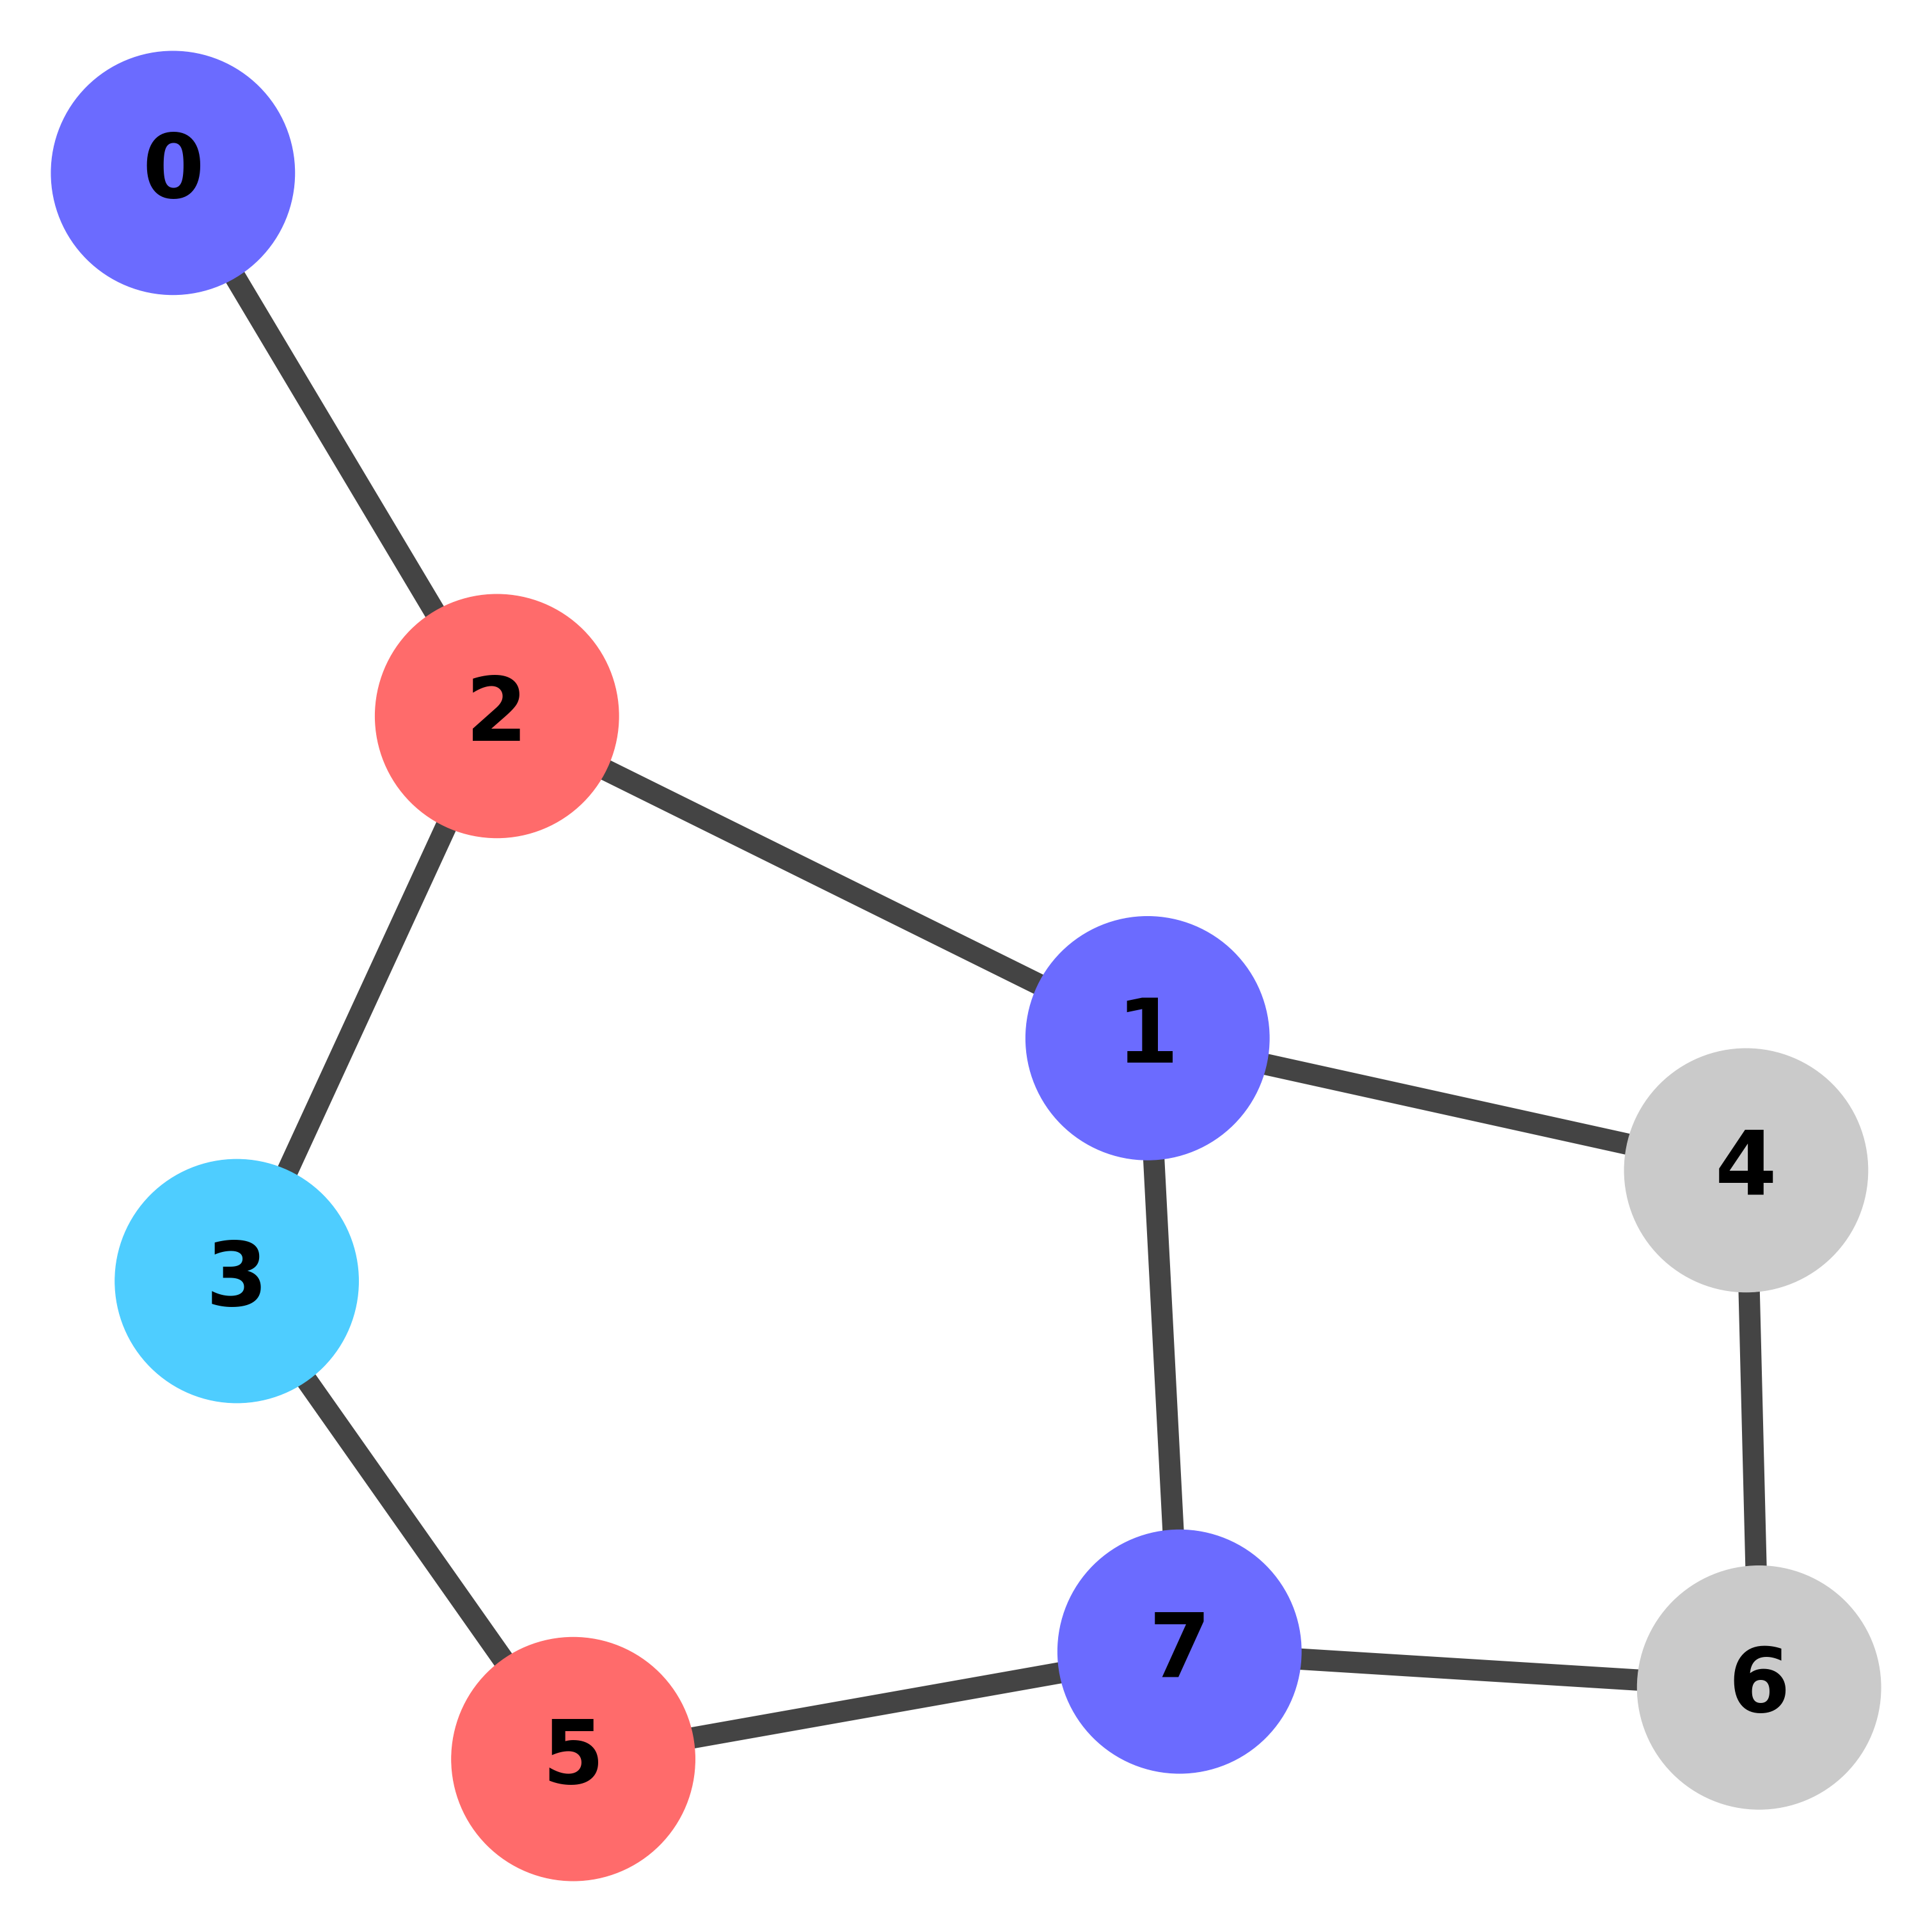

In [79]:
community_color = "#6B6BFF"


node_colors_2 = [
    community_color,
    community_color,
    neighbour_color,
    agent_color,
    node_color,
    neighbour_color,
    node_color,
    community_color,
]


# nx.draw(G_1, with_labels=True, pos=pos_1)

plt.figure(figsize=(30, 30))
nx.draw(
    G_1,
    pos=pos_1,
    node_color=node_colors_2,
    node_size=75000,
    node_shape="o",
    edge_color="#444444",
    width=24,
    with_labels=True,
    font_size=100,
    font_color="black",
    font_weight="bold",
)

In [80]:
seed_1 = 42
size_1 = 80
G_2 = nx.gnp_random_graph(size_1, 0.2, seed=seed_1)
M_1: Market = Market(size_1, G_2, agent_type=OptimizerAgent, seed=seed_1, k=4)
M_2: Market = Market(size_1, G_2, agent_type=ProportionalAgent, seed=seed_1)

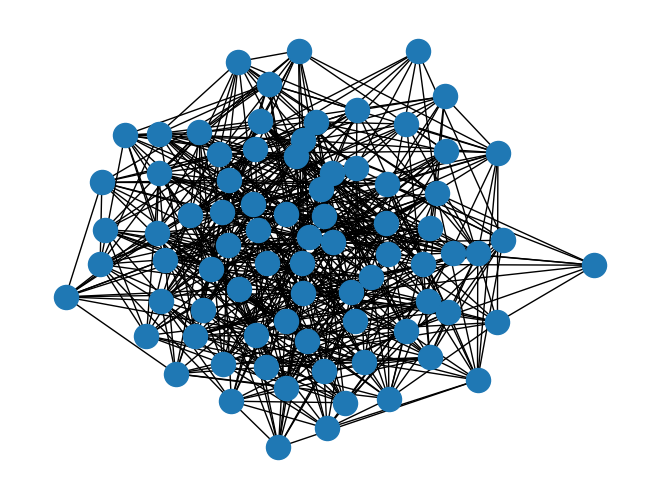

In [81]:
nx.draw(G_2)

In [82]:
eq_allocation, eq_utility = P4(M_1)

M_1.set_market_equilibrium(eq_allocation, eq_utility)
M_2.set_market_equilibrium(eq_allocation, eq_utility)

In [83]:
simulation_length = 50

optimizer_simulation_results = M_1.simulate(simulation_length)
proportional_simulation_results = M_2.simulate(simulation_length)

/home/joeri/Projects/RP/Ant/.venv/lib/python3.14/site-packages/cvxpy/atoms/elementwise/log.py:35: RuntimeWarning: invalid value encountered in log
  return np.log(values[0])
/home/joeri/Projects/RP/Ant/src/ant/decentralised/dynamic.py:82: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  result = prob.solve(verbose=False)


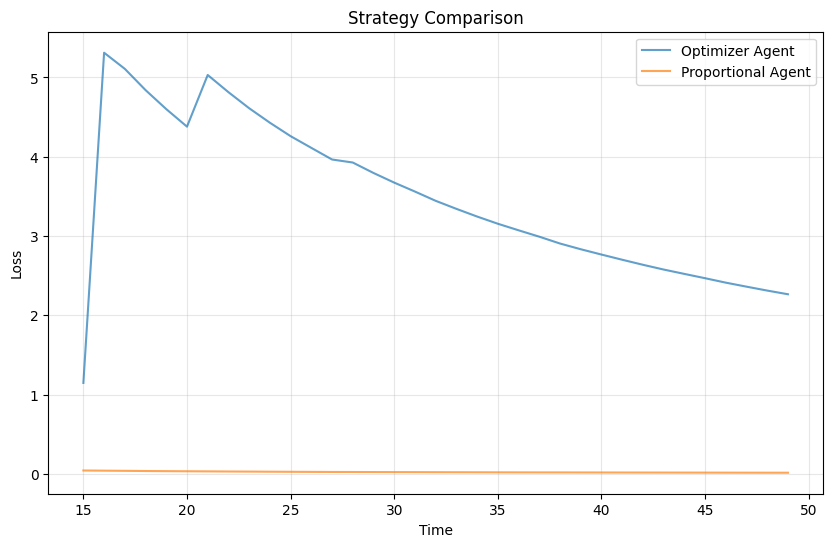

In [84]:
training_period = 15
time_steps = np.arange(training_period, simulation_length)

plt.figure(figsize=(10, 6))
plt.plot(
    time_steps,
    optimizer_simulation_results[training_period:],
    label="Optimizer Agent",
    alpha=0.7,
)
plt.plot(
    time_steps,
    proportional_simulation_results[training_period:],
    label="Proportional Agent",
    alpha=0.7,
)

plt.xlabel("Time")
plt.ylabel("Loss")
plt.title("Strategy Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()